In [25]:
import sys; sys.path.insert(0, "..")
import numpy as np
import matplotlib.pyplot as plt
import src.analysis as an

TAU = 128
res = an.load_results(TAU)
ok  = [r for r in res if r["has_ckpt"]]          # runs we can actually load

print(f"tau={TAU}: {len(res)} results, {len(ok)} with checkpoints")
print("times:", [round(r["t_used"], 1) for r in res])
if len(ok) < len(res):
    print("missing .pt for:", [round(r["t_used"],1) for r in res if not r["has_ckpt"]])

tau=128: 9 results, 4 with checkpoints
times: [-64.0, -32.0, 0.0, 12.8, 25.6, 38.4, 51.2, 64.0, 96.0]
missing .pt for: [25.6, 38.4, 51.2, 64.0, 96.0]


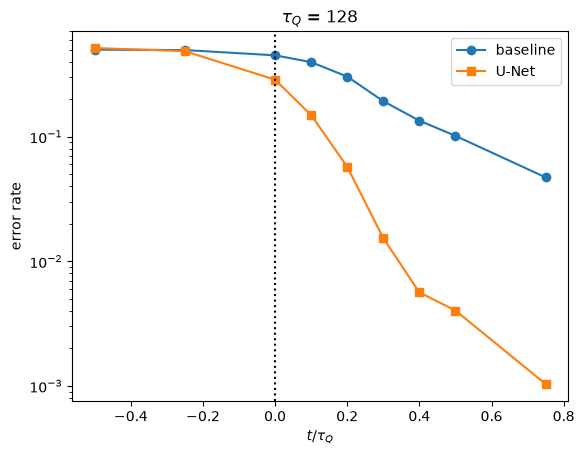

threshold 0.4:  t*/tau = -0.142
threshold 0.3:  t*/tau = -0.016
threshold 0.25:  t*/tau = 0.027
threshold 0.2:  t*/tau = 0.063


In [26]:
t, eb, em = an.as_arrays(res)

plt.semilogy(t/TAU, eb, "o-", label="baseline")
plt.semilogy(t/TAU, em, "s-", label="U-Net")
plt.axvline(0, color="k", ls=":")
plt.xlabel("$t/\\tau_Q$"); plt.ylabel("error rate")
plt.title(f"$\\tau_Q$ = {TAU}"); plt.legend()
plt.show()

for thr in [0.4, 0.3, 0.25, 0.2]:
    print(f"threshold {thr}:  t*/tau = {an.t_star(res, TAU, thr):.3f}")

In [27]:
d  = an.load_chunk(TAU)
xi = an.correlation_length(d["phi_final"])
wl = an.wall_length(d["phi_final"])
print(f"xi   = {xi.mean():5.1f} ± {xi.std():.1f} sites   (box = 128)")
print(f"wall = {wl.mean():5.0f} ± {wl.std():.0f}")

xi   =  28.9 ± 3.9 sites   (box = 128)
wall =   131 ± 64


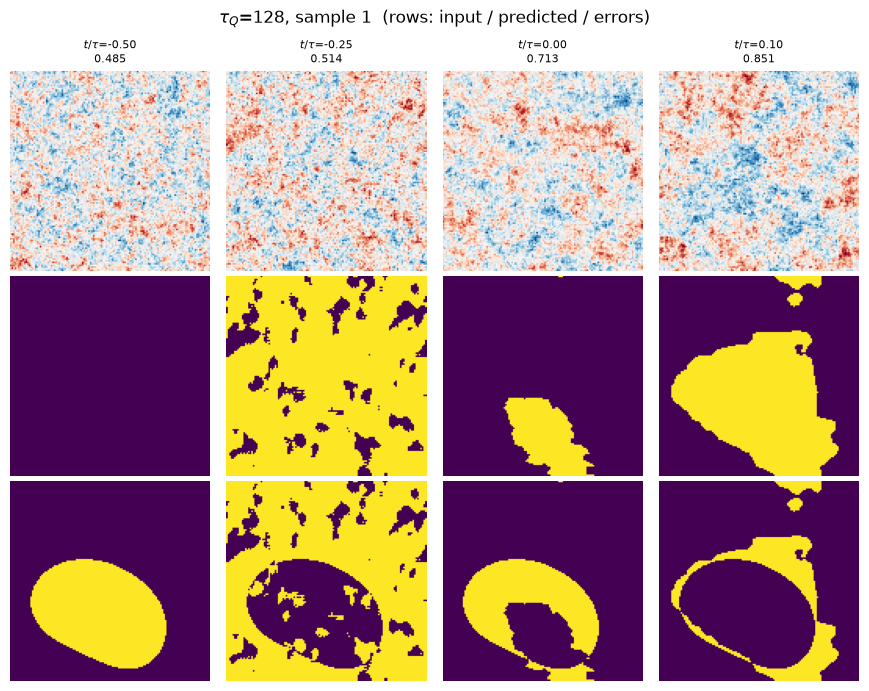

In [29]:
SAMPLE = 1
Y = (d["phi_final"] > 0)[SAMPLE]

n = len(ok)
fig, axes = plt.subplots(3, n, figsize=(2.2*n, 7))
for col, r in enumerate(ok):
    model, meta = an.load_model(r["tag"])
    X, t_used = an.snapshot_at(d, meta["t_used"])
    p = an.predict(model, X, meta["scale"])[SAMPLE]

    axes[0, col].imshow(X[SAMPLE], cmap="RdBu")
    axes[0, col].set_title(f"$t/\\tau$={t_used/TAU:.2f}\n{meta['test_acc']:.3f}", fontsize=8)
    axes[1, col].imshow(p)
    axes[2, col].imshow(p != Y)
for a in axes.ravel(): a.axis("off")
plt.suptitle(f"$\\tau_Q$={TAU}, sample {SAMPLE}  (rows: input / predicted / errors)")
plt.tight_layout(); plt.show()

In [31]:
TAUS  = [32, 64, 128]
THRS  = [0.4, 0.3, 0.25, 0.2]

allres = {}
tstar  = {thr: [] for thr in THRS}

print(f"{'tau':>5} {'n':>3} " + " ".join(f"{thr:>8}" for thr in THRS))
for tau in TAUS:
    res = an.load_results(tau)
    allres[tau] = res
    row = [an.t_star(res, tau, thr) for thr in THRS]
    for thr, v in zip(THRS, row):
        tstar[thr].append(v)
    print(f"{tau:>5} {len(res):>3} " + " ".join(f"{v:>8.3f}" for v in row))

  tau   n      0.4      0.3     0.25      0.2
   32   9   -0.205   -0.038    0.039    0.113
   64   9   -0.168   -0.050    0.009    0.066
  128   9   -0.142   -0.016    0.027    0.063


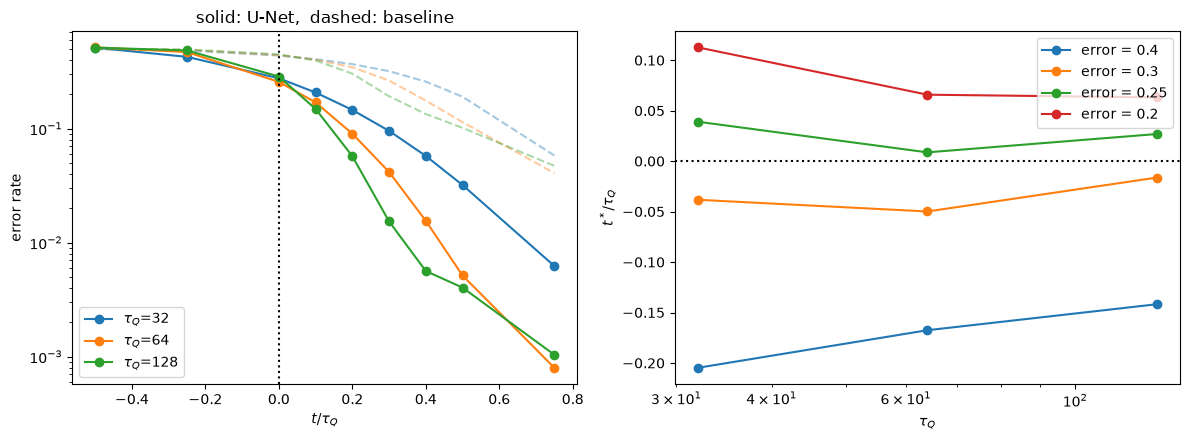

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# left: all error curves, rescaled time
for tau in TAUS:
    t, eb, em = an.as_arrays(allres[tau])
    axes[0].semilogy(t/tau, em, "o-",  label=f"$\\tau_Q$={tau}")
    axes[0].semilogy(t/tau, eb, "--", color=axes[0].lines[-1].get_color(), alpha=0.4)
axes[0].axvline(0, color="k", ls=":")
axes[0].set_xlabel("$t/\\tau_Q$"); axes[0].set_ylabel("error rate")
axes[0].set_title("solid: U-Net,  dashed: baseline")
axes[0].legend()

# right: t* vs tau, one line per threshold
for thr in THRS:
    axes[1].plot(TAUS, tstar[thr], "o-", label=f"error = {thr}")
axes[1].set_xscale("log")
axes[1].axhline(0, color="k", ls=":")
axes[1].set_xlabel("$\\tau_Q$"); axes[1].set_ylabel("$t^*/\\tau_Q$")
axes[1].legend()

plt.tight_layout()
plt.savefig("../figures/collapse_and_tstar.png", dpi=150)
plt.show()

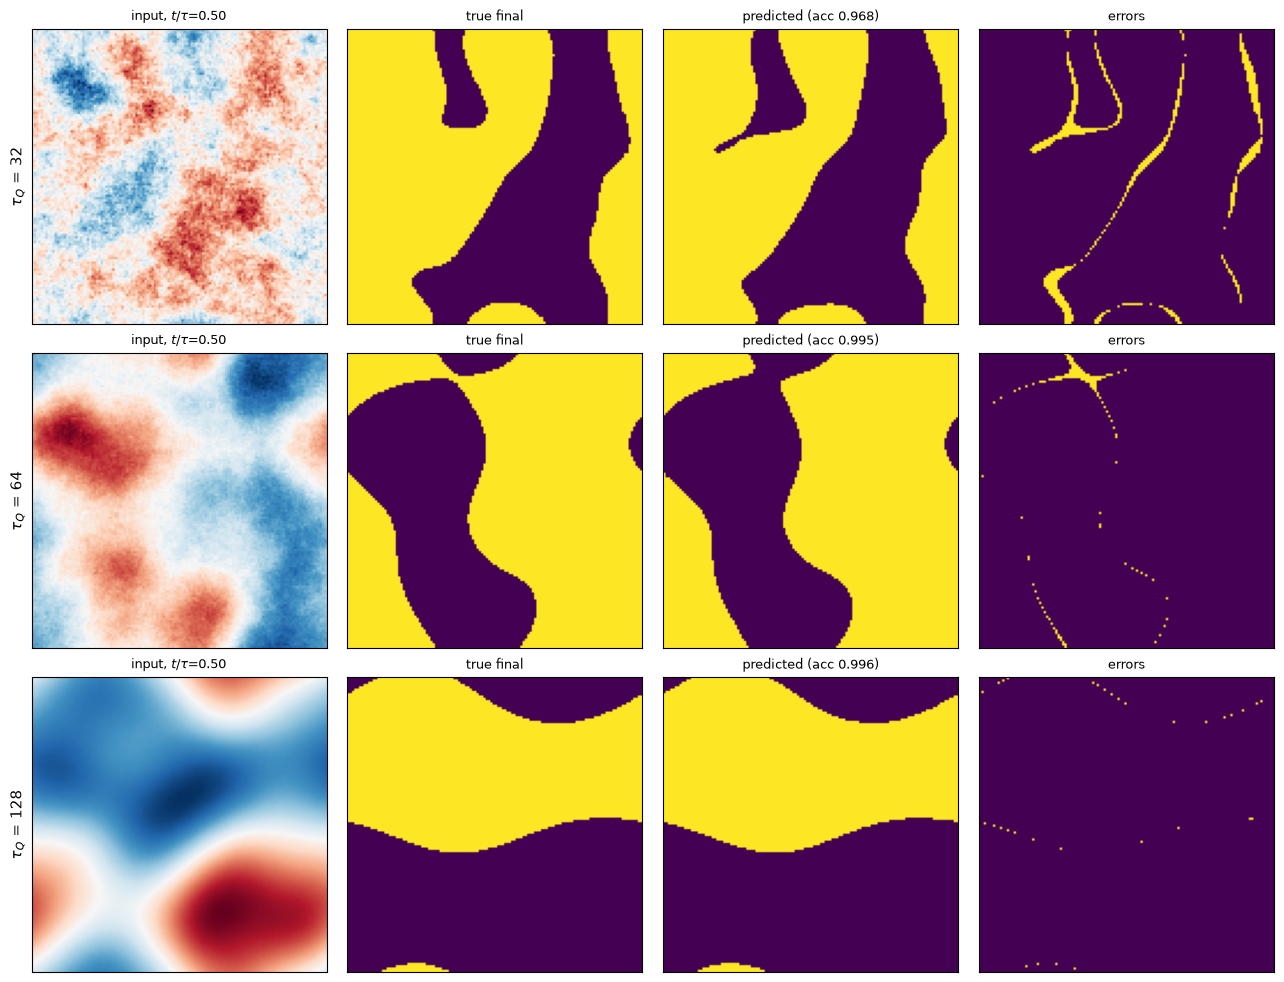

In [41]:
T_FRAC = 0.5          # t/tau to look at
SAMPLE = 0

fig, axes = plt.subplots(len(TAUS), 4, figsize=(13, 3.3*len(TAUS)))

for row, tau in enumerate(TAUS):
    d   = an.load_chunk(tau)
    res = [r for r in an.load_results(tau) if r["has_ckpt"]]
    # closest trained model to T_FRAC
    r   = min(res, key=lambda r: abs(r["t_used"]/tau - T_FRAC))

    model, meta = an.load_model(r["tag"])
    X, t_used   = an.snapshot_at(d, meta["t_used"])
    pred = an.predict(model, X, meta["scale"])[SAMPLE]
    Y    = (d["phi_final"] > 0)[SAMPLE]

    axes[row, 0].imshow(X[SAMPLE], cmap="RdBu")
    axes[row, 1].imshow(Y)
    axes[row, 2].imshow(pred)
    axes[row, 3].imshow(pred != Y)

    axes[row, 0].set_ylabel(f"$\\tau_Q$ = {tau}", fontsize=11)
    axes[row, 0].set_title(f"input, $t/\\tau$={t_used/tau:.2f}", fontsize=9)
    axes[row, 1].set_title("true final", fontsize=9)
    axes[row, 2].set_title(f"predicted (acc {meta['test_acc']:.3f})", fontsize=9)
    axes[row, 3].set_title("errors", fontsize=9)
    for a in axes[row]:
        a.set_xticks([]); a.set_yticks([])

plt.tight_layout()
plt.savefig(f"../figures/across_tau_frac{T_FRAC}.png", dpi=150)
plt.show()

In [39]:
for tau in TAUS:
    have = [round(r["t_used"]/tau, 2) for r in an.load_results(tau) if r["has_ckpt"]]
    print(tau, have)

32 [-0.5, -0.25, 0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.75]
64 [-0.5, -0.25, 0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.75]
128 [-0.5, -0.25, 0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.75]


In [38]:
qstat -u kmunnik
ls /projectnb/fheating/kmunnik/MachineLearningKZ/results/*.pt | wc -l

SyntaxError: invalid syntax (1791727937.py, line 1)